# **1. Simple Linear Regression**



In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Sample dataset
X = np.array([800, 1200, 1500, 1800, 2200]).reshape(-1,1)  # Independent variable (square footage)
y = np.array([150000, 180000, 220000, 250000, 280000])  # Dependent variable (price)

# Train Model
model = LinearRegression()
model.fit(X, y)

# Predict
y_pred = model.predict([[2000]])  # Predict price for 2000 sqft house
print("Predicted Price:", y_pred[0])

Predicted Price: 264275.8620689655


# **2. Multiple Linear Regression**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Sample dataset
data = {
    'SquareFootage': [800, 1200, 1500, 1800, 2200],
    'Bedrooms': [2, 3, 3, 4, 4],
    'Price': [150000, 180000, 220000, 250000, 280000]
}
df = pd.DataFrame(data)

# Define independent and dependent variables
X = df[['SquareFootage', 'Bedrooms']]
y = df['Price']

# Split data and train model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)
print("Predicted Prices:", y_pred)

Predicted Prices: [192916.66666667]


# **3. Polynomial Regression**

Predicted COVID-19 cases on Day 11: 17174


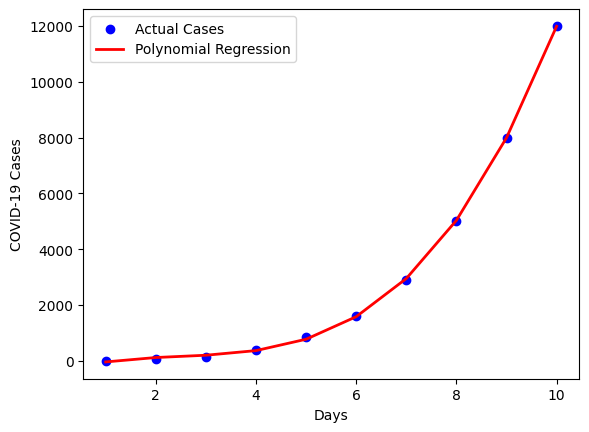

In [ ]:
# Step 1: Import Required Libraries
import numpy as np  # For numerical operations
import matplotlib.pyplot as plt  # For data visualization
from sklearn.preprocessing import PolynomialFeatures  # To generate polynomial features
from sklearn.linear_model import LinearRegression  # Linear model for polynomial regression

# Step 2: Create a Dataset (Days vs. COVID-19 Cases)
X = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]).reshape(-1, 1)
y = np.array([10, 50, 150, 400, 850, 1600, 2900, 5000, 8000, 12000])

# Step 3: Transform Features to Polynomial Form (Degree = 3)
poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(X)

# Step 4: Train the Polynomial Regression Model
model = LinearRegression()
model.fit(X_poly, y)

# Step 5: Predict Cases for Day 11
X_test = np.array([11]).reshape(-1, 1)
X_test_poly = poly.transform(X_test)
y_pred = model.predict(X_test_poly)

print(f"Predicted COVID-19 cases on Day 11: {int(y_pred[0])}")

# Step 6: Plot the Data and Regression Curve
plt.scatter(X, y, color='blue', label="Actual Cases")
plt.plot(X, model.predict(X_poly), color='red', linewidth=2, label="Polynomial Regression")
plt.xlabel("Days")
plt.ylabel("COVID-19 Cases")
plt.legend()
plt.show()

# **4. Ridge and Lasso Regression**

Ridge Regression - MSE: 560231827.72, R²: 0.96
Lasso Regression - MSE: 139457861.91, R²: 0.99

Ridge Regression Coefficients:
SquareFootage     45264.050610
Bedrooms          36349.371124
Age                -443.221715
DistanceToCity    -6272.008243
dtype: float64

Lasso Regression Coefficients:
SquareFootage     77843.030221
Bedrooms          19447.315169
Age               -1095.182461
DistanceToCity     5385.420600
dtype: float64


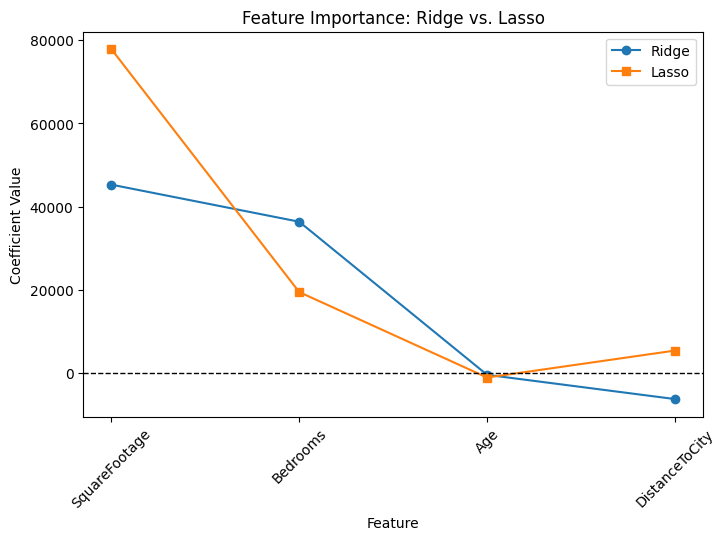

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score



# Sample dataset
data = {
    'SquareFootage': [800, 1200, 1500, 1800, 2200, 2500, 2800, 3200, 3500, 4000],
    'Bedrooms': [2, 3, 3, 4, 4, 5, 5, 6, 6, 7],
    'Age': [10, 5, 15, 20, 8, 12, 7, 3, 25, 30],  # Age of the house
    'DistanceToCity': [10, 8, 12, 5, 7, 4, 6, 3, 2, 1],  # Miles from city center
    'Price': [150000, 180000, 220000, 250000, 280000, 310000, 350000, 390000, 420000, 460000]
}

df = pd.DataFrame(data)



# Define independent (X) and dependent (y) variables
X = df[['SquareFootage', 'Bedrooms', 'Age', 'DistanceToCity']]  # Features
y = df['Price']  # Target variable



# Split data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize the features (Scaling helps in Ridge/Lasso regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



# Ridge Regression (L2 Regularization)
ridge = Ridge(alpha=1.0)  # Alpha controls regularization strength
ridge.fit(X_train_scaled, y_train)

# Lasso Regression (L1 Regularization)
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)



# Make predictions
ridge_preds = ridge.predict(X_test_scaled)
lasso_preds = lasso.predict(X_test_scaled)

# Compute MSE and R² Score
ridge_mse = mean_squared_error(y_test, ridge_preds)
ridge_r2 = r2_score(y_test, ridge_preds)

lasso_mse = mean_squared_error(y_test, lasso_preds)
lasso_r2 = r2_score(y_test, lasso_preds)

print(f"Ridge Regression - MSE: {ridge_mse:.2f}, R²: {ridge_r2:.2f}")
print(f"Lasso Regression - MSE: {lasso_mse:.2f}, R²: {lasso_r2:.2f}")



# Print coefficients
ridge_coefs = pd.Series(ridge.coef_, index=X.columns)
lasso_coefs = pd.Series(lasso.coef_, index=X.columns)

print("\nRidge Regression Coefficients:")
print(ridge_coefs)

print("\nLasso Regression Coefficients:")
print(lasso_coefs)



plt.figure(figsize=(8, 5))

# Plot Ridge and Lasso coefficients
plt.plot(ridge_coefs, label="Ridge", marker='o')
plt.plot(lasso_coefs, label="Lasso", marker='s')
plt.axhline(0, color='black', linestyle="--", linewidth=1)
plt.legend()
plt.title("Feature Importance: Ridge vs. Lasso")
plt.xlabel("Feature")
plt.ylabel("Coefficient Value")
plt.xticks(rotation=45)
plt.show()

# **5. Support Vector Regression(SVR)**

In [ ]:
from sklearn.svm import SVR

# Train Support Vector Regression Model
svr = SVR(kernel='rbf')
svr.fit(X_train, y_train)

# Predict
y_pred = svr.predict(X_test)
print("SVR Predictions:", y_pred)

SVR Predictions: [295001.7208667  294998.29045998]


# **Chosen Regression: Polynomial Regression (Years of Experience vs Salary Growth)**


LINEAR REGRESSION
R2 Score: 0.9379722710296805
MSE: 273.26660596368515

POLYNOMIAL REGRESSION (Degree 4)
R2 Score: 0.9909477456841996
MSE: 39.880209291276124

Future Salary Predictions (in ₱1000s):
22 years experience: ₱239k
25 years experience: ₱266k


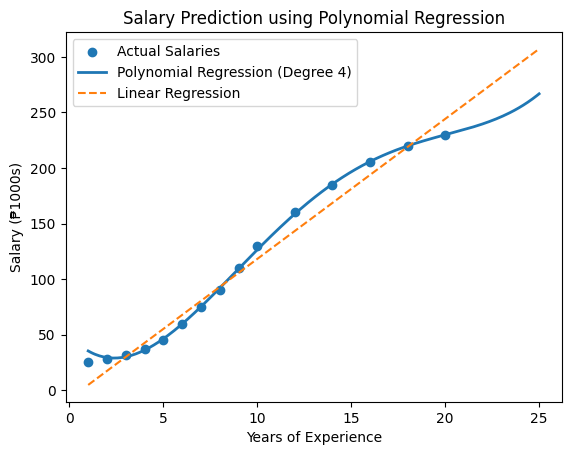

In [ ]:
# Step 1: Import Required Libraries
import numpy as np  # For numerical operations
import matplotlib.pyplot as plt  # For data visualization
from sklearn.preprocessing import PolynomialFeatures  # To generate polynomial features
from sklearn.linear_model import LinearRegression  # Linear model for polynomial regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Step 2: Create a Dataset (Years of Experience vs Salary Growth )
X = np.array([1,2,3,4,5,6,7,8,9,10,12,14,16,18,20]).reshape(-1, 1)
y = np.array([25,28,32,37,45,60,75,90,110,130,160,185,205,220,230])

#Splitting Dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_linear_pred = linear_model.predict(X_test)

# Step 3: Transform Features to Polynomial Form (Degree = 4)
poly = PolynomialFeatures(degree=4)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

y_poly_pred = poly_model.predict(X_test_poly)

# Step 4: Evaluation
print("LINEAR REGRESSION")
print("R2 Score:", r2_score(y_test, y_linear_pred))
print("MSE:", mean_squared_error(y_test, y_linear_pred))

print("\nPOLYNOMIAL REGRESSION (Degree 4)")
print("R2 Score:", r2_score(y_test, y_poly_pred))
print("MSE:", mean_squared_error(y_test, y_poly_pred))

# Step 5: Predict Future Salaries (25 Years Experience)
future_years = np.array([22, 25]).reshape(-1,1)
future_poly = poly.transform(future_years)
future_predictions = poly_model.predict(future_poly)

print("\nFuture Salary Predictions (in ₱1000s):")
for year, pred in zip(future_years, future_predictions):
    print(f"{year[0]} years experience: ₱{int(pred)}k")

# Step 6: Plot the Data and Regression Curve
X_range = np.linspace(1, 25, 200).reshape(-1,1)
X_range_poly = poly.transform(X_range)

plt.scatter(X, y, label="Actual Salaries")
plt.plot(X_range, poly_model.predict(X_range_poly), linewidth=2,
         label="Polynomial Regression (Degree 4)")
plt.plot(X_range, linear_model.predict(X_range), linestyle='dashed',
         label="Linear Regression")

plt.xlabel("Years of Experience")
plt.ylabel("Salary (₱1000s)")
plt.title("Salary Prediction using Polynomial Regression")
plt.legend()
plt.show()